In [180]:
import numpy as np
import pandas as pd
df=pd.read_csv("taxi.csv")
df['store_and_fwd_flag']=df['store_and_fwd_flag'].replace({'N':1})
print(df)
df.describe()
df.info()
df['tpep_pickup_datetime']=pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime']=pd.to_datetime(df['tpep_dropoff_datetime'])

     VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2.0  2019-07-15 16:27:53   2019-07-15 16:44:21              3.0   
1         2.0  2019-07-17 20:26:35   2019-07-17 20:40:09              6.0   
2         2.0  2019-07-06 16:01:08   2019-07-06 16:10:25              1.0   
3         1.0  2019-07-18 22:32:23   2019-07-18 22:35:08              1.0   
4         2.0  2019-07-19 14:54:29   2019-07-19 15:19:08              1.0   
..        ...                  ...                   ...              ...   
195       2.0  2019-01-18 08:42:15   2019-01-18 08:56:57              1.0   
196       1.0  2019-01-19 04:34:45   2019-01-19 04:43:44              1.0   
197       2.0  2019-01-05 10:37:39   2019-01-05 10:42:03              1.0   
198       2.0  2019-01-23 10:36:29   2019-01-23 10:44:34              2.0   
199       2.0  2019-01-30 06:55:58   2019-01-30 07:07:02              5.0   

     trip_distance  RatecodeID  store_and_fwd_flag  PULocationID  \
0      

/var/folders/rj/yzdtrlc11gz0vt7njkp70yf80000gn/T/ipykernel_6865/654638983.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['store_and_fwd_flag']=df['store_and_fwd_flag'].replace({'N':1})


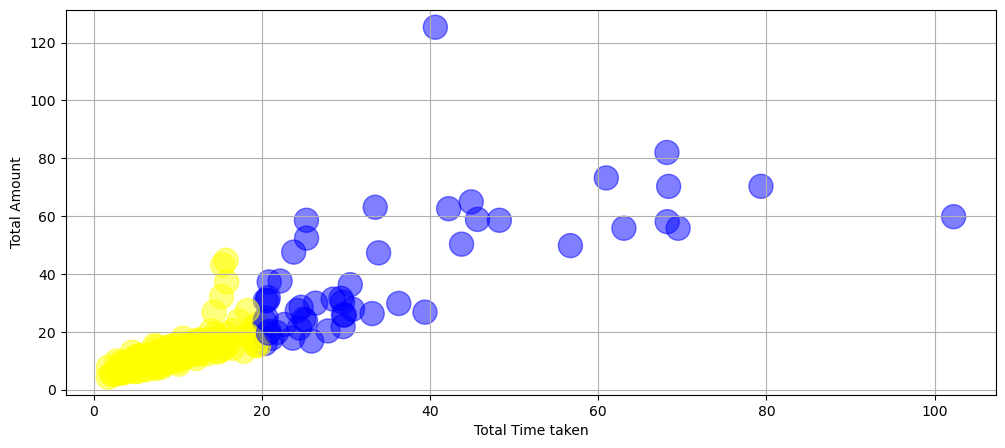

In [ ]:
pickup_time=pd.to_datetime(df['tpep_pickup_datetime'])
dropoff_time=pd.to_datetime(df['tpep_dropoff_datetime'])
df['total_time_taken']=dropoff_time - pickup_time
df['total_time_taken'].describe()
duration=df['total_time_taken'].dt.total_seconds()/60
colors=np.where(duration>20,'blue','yellow')
fig,ax=plt.subplots(figsize=(12,5))
ax.scatter(duration,df['total_amount'],c=colors,s=300,alpha=0.5)
ax.set_ylabel("Total Amount")
ax.set_xlabel("Total Time taken")
plt.grid(True)

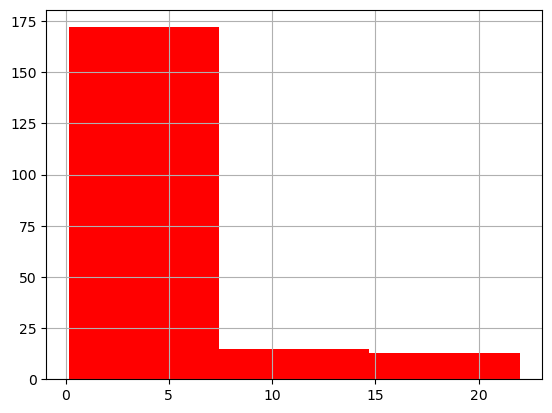

In [182]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots()
ax.hist(df['trip_distance'],bins=3,color='red',linewidth=3)
plt.grid(True)


<Axes: >

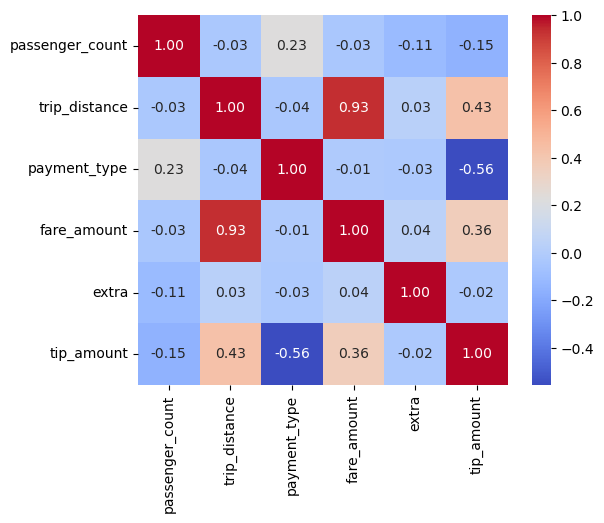

In [183]:
import seaborn as sns
correlation_matrix=df[['passenger_count','trip_distance','payment_type','fare_amount','extra','tip_amount']].corr()
sns.heatmap(correlation_matrix,cmap='coolwarm',annot=True,fmt='.2f',square=True)


count    200.000000
mean      20.154350
std       17.072769
min        4.300000
25%       10.215000
50%       14.120000
75%       22.552500
max      125.300000
Name: total_amount, dtype: float64

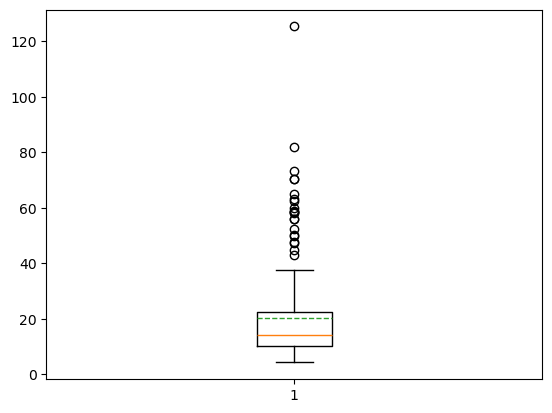

In [184]:
plt.boxplot(df['total_amount'],showmeans=True,meanline=True,showfliers=True)
df['total_amount'].describe()

Text(0.5, 1.0, 'Total Amount segrigation')

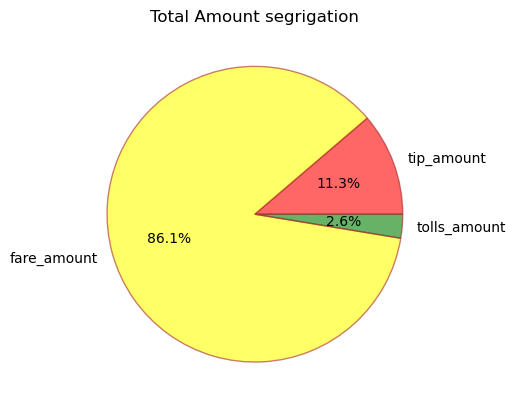

In [ ]:
df1=df[['tip_amount','fare_amount','tolls_amount']].sum()
plt.pie(df1,autopct='%.1f%%',colors=['red','yellow','green'],labels=df1.index,wedgeprops={'alpha':0.6,'edgecolor':'brown'})
plt.title("Total Amount segrigation")

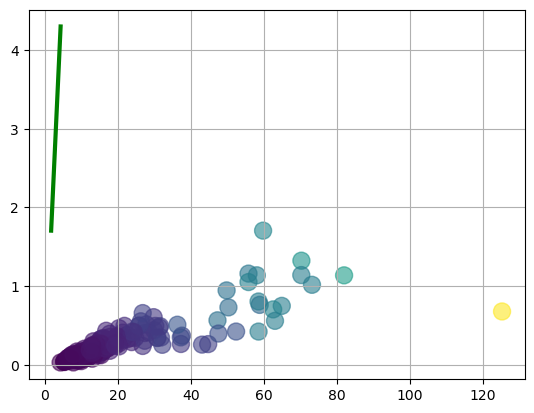

In [186]:
df['total_time_taken']=(df['total_time_taken'].dt.total_seconds())/3600
plt.plot([df['total_amount'].min(),df['total_time_taken'].max()],[df['total_amount'].min(),df['total_time_taken'].max()],color='green',linewidth=3)
plt.scatter(df['total_amount'],df['total_time_taken'],c=df['fare_amount'],cmap='viridis',alpha=0.6,s=150)
plt.grid(True)

VendorID                        float64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                int64
PULocationID                      int64
DOLocationID                      int64
payment_type                    float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
total_time_taken                float64
profit                          float64
dtype: object


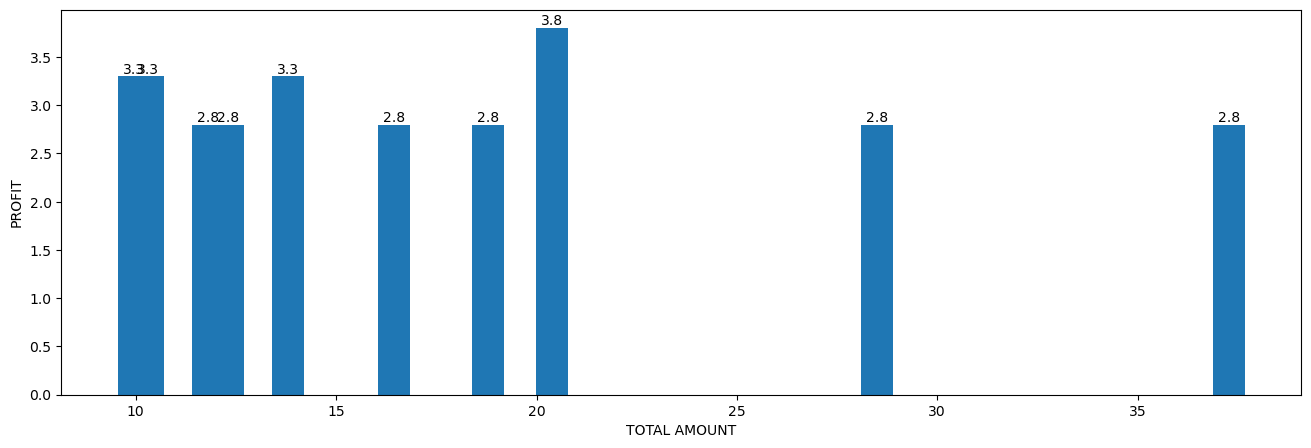

In [187]:
df['profit']=df['total_amount']-df['fare_amount']-df['tip_amount']-df['mta_tax']-df['tolls_amount']
# print(df['profit'])
fig,ax=plt.subplots(figsize=(16,5))
bars=ax.bar(df['total_amount'].iloc[:10],df['profit'].iloc[:10])
plt.ylabel("PROFIT")
plt.xlabel("TOTAL AMOUNT")
plt.bar_label(bars)
print(df.dtypes)



Mean absolute error 2.0792310099780122
R2 Score: 0.927750777073141
DecisionTreeRegressor(max_depth=4, max_features=1.0, min_samples_leaf=5,
                      min_samples_split=5, random_state=1608637542)
[64.0169667  54.35862128 51.24450284 37.76173259 33.8429224  30.37126415
 23.68348462 20.30121166 17.4082116  17.16304778 16.13796432 15.37430968
 15.27416531 15.19715407 14.8554813  13.576938   13.54253568 13.53906963
 13.43756676 13.30197231 13.12373756 12.95196463 12.81646978 12.79300822
 12.61479867 11.86952244 11.31049509 11.02636913 10.80196575 10.04058555
  9.91982584  9.89813204  8.95137433  8.85551178  8.62986727  8.39669614
  8.28670905  7.94105851  7.55773002  7.38323347]


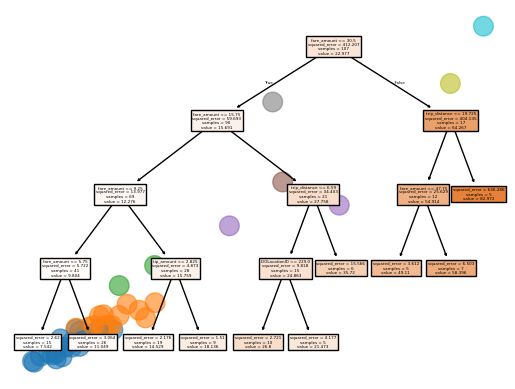

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
df['store_and_fwd_flag']=df['store_and_fwd_flag'].replace({'N':0,'Y':1})
X=df.drop(['total_amount','total_time_taken','tpep_dropoff_datetime','tpep_pickup_datetime'],axis=1)
y=df['total_amount']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=RandomForestRegressor(max_depth=4,min_samples_leaf=5,min_samples_split=5,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Mean absolute error",mean_absolute_error(y_test,y_pred))
print("R2 Score:",r2_score(y_test,y_pred))
plot_tree(model.estimators_[0],feature_names=X.columns,filled=True,max_depth=5)
print(model.estimators_[0])
# plt.plot([y_test.min(),y_pred.max()],[y_test.min(),y_pred.max()],color='red',linewidth=2)
plt.scatter(y_test,y_pred,c=y_pred,cmap='tab10',s=200,alpha=0.6)
y_pred=np.sort(y_pred)[::-1]
print(y_pred)


    